In [2]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm # Assuming tqdm is imported


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [14]:
train_df = pd.read_csv("../Datasets/train.csv")
val_df = pd.read_csv("../Datasets/val.csv")
test_df = pd.read_csv("../Datasets/test.csv")
PROC_DIR = "."
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Train samples: 36916
Validation samples: 6515
Test samples: 7665


In [15]:
# --- FIX: Re-encode the string labels to integers after reading CSVs ---
le = LabelEncoder()

In [16]:
all_labels = pd.concat([train_df['label'], val_df['label'], test_df['label']])
le.fit(all_labels)

LabelEncoder()

In [17]:
# Apply the transformation back to the dataframes' 'label' column
train_df['label'] = le.transform(train_df['label'])
val_df['label'] = le.transform(val_df['label'])
test_df['label'] = le.transform(test_df['label'])

In [18]:
# ---------------- Keypoint Augmentation Helpers ------------------
def random_scaling(x_seq, scale_range=(0.9, 1.1)):
    s = np.random.uniform(scale_range[0], scale_range[1])
    return x_seq * s

def random_rotation(x_seq, max_angle=10):
    theta = np.radians(np.random.uniform(-max_angle, max_angle))
    cos_val, sin_val = np.cos(theta), np.sin(theta)
    R = np.array([[cos_val, -sin_val, 0],
                  [sin_val, cos_val, 0],
                  [0, 0, 1]], dtype=np.float32)
    T = x_seq.shape[0]
    x_reshaped = x_seq.reshape(T, 129, 3)
    x_rotated = np.dot(x_reshaped, R.T)
    return x_rotated.reshape(T, -1)

def add_noise(x_seq, noise_level=0.01):
    noise = np.random.normal(0, noise_level, x_seq.shape)
    mask = (x_seq != 0.0)
    x_seq[mask] += noise[mask]
    return x_seq

def augment_sequence(x_seq):
    if np.random.rand() < 0.5:
        x_seq = random_scaling(x_seq)
    if np.random.rand() < 0.5:
        x_seq = random_rotation(x_seq)
    if np.random.rand() < 0.5:
        x_seq = add_noise(x_seq)
    return x_seq

# ---------------- Dataset Loader with Augmentation ------------------
class SignDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df
        self.augment = augment

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(f"{PROC_DIR}/{row.file}").astype(np.float32)
        
        if self.augment:
            x = augment_sequence(x)
            
        y = int(row.label)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.df)


In [19]:
train_loader = DataLoader(SignDataset(train_df, augment=True), batch_size=32, shuffle=True)
val_loader   = DataLoader(SignDataset(val_df, augment=False),   batch_size=32, shuffle=False)
test_loader  = DataLoader(SignDataset(test_df, augment=False),  batch_size=32, shuffle=False)


In [20]:
sample_batch_X, sample_batch_y = next(iter(train_loader))
input_dim = sample_batch_X.shape[-1] # Gets the actual last dimension: 387

num_classes = train_df.label.nunique()
print(f"Dynamically determined input_dim: {input_dim}")
print(f"Number of classes: {num_classes}")

Dynamically determined input_dim: 387
Number of classes: 401


In [21]:
# ---------------- EarlyStopping Class (Directory Aware) -----------------------
class EarlyStopping:
    """Stops training when validation loss does not improve for a given patience."""
    def __init__(self, patience=5, verbose=False, delta=0, filename='checkpoint.pt', save_dir='Models'):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.save_dir = save_dir
        # Combine directory and filename for the full path
        self.path = os.path.join(save_dir, filename) 
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        
        # Ensure the save directory exists before any saving happens
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir, exist_ok=True)
            if self.verbose:
                print(f"Created directory: {self.save_dir}")

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Saves model when validation loss decreases."""
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model to {self.path}...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# CNN-BiLSTM with Attention Model
In this section, we define, train, and evaluate a CNN-BiLSTM model with a Self-Attention mechanism over the LSTM outputs. This architecture uses 1D temporal convolutions to extract local temporal patterns from the normalized keypoint sequences, followed by a bidirectional LSTM to model longer-term dependencies, and an attention pooling layer to highlight the most informative timesteps.

In [22]:
import torch
import torch.nn as nn

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_dim=387, num_classes=401, conv_filters=128, lstm_hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        # Input shape: (B, T, F)
        # conv1 expects channels first, so we will transpose the input to (B, F, T)
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_dim, out_channels=conv_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_filters),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=conv_filters, out_channels=conv_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_filters),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # BiLSTM layer
        self.lstm = nn.LSTM(
            input_size=conv_filters,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        # Self-attention mechanism over the LSTM outputs (lstm_hidden * 2 due to bidirectionality)
        self.attention = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)
        
    def forward(self, x):
        # x shape: (B, T, F)
        # Transpose for Conv1d: (B, F, T)
        x = x.transpose(1, 2)
        x = self.conv1(x) # (B, conv_filters, T)
        x = self.conv2(x) # (B, conv_filters, T)
        
        # Transpose back for LSTM: (B, T, conv_filters)
        x = x.transpose(1, 2)
        
        # LSTM forward
        lstm_out, _ = self.lstm(x) # (B, T, lstm_hidden * 2)
        
        # Attention weights
        attn_weights = self.attention(lstm_out) # (B, T, 1)
        attn_weights = torch.softmax(attn_weights, dim=1) # (B, T, 1)
        
        # Context vector (weighted sum of LSTM outputs)
        context = torch.sum(lstm_out * attn_weights, dim=1) # (B, lstm_hidden * 2)
        
        # Classification layer
        out = self.fc(context)
        return out

In [23]:
# Initialize the model, loss, and optimizer
cnn_model = CNNBiLSTMAttention(input_dim=input_dim, num_classes=num_classes).to(device)
cnn_loss_fn = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-4)

print(cnn_model)

CNNBiLSTMAttention(
  (conv1): Sequential(
    (0): Conv1d(387, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Linear(in_features=256, out_features=401, bias=True)
)


In [24]:
# Training loop for CNN-BiLSTM with Attention
EPOCHS = 150
cnn_train_losses, cnn_val_losses = [], []
cnn_train_accs, cnn_val_accs = [], []

cnn_early_stopping = EarlyStopping(
    patience=7, 
    verbose=True,
    save_dir='../Models',          # Saves to the parent directory's 'Models' folder
    filename='cnn_bilstm_attention_frontveiw.pth'   # Desired filename
)

for epoch in range(EPOCHS):
    cnn_model.train()
    total_loss, correct = 0, 0

    for X, y in tqdm(train_loader, desc=f"CNN-BiLSTM Epoch {epoch+1}/{EPOCHS}"):
        X, y = X.to(device), y.to(device)

        cnn_optimizer.zero_grad()
        preds = cnn_model(X)
        loss = cnn_loss_fn(preds, y)
        loss.backward()
        cnn_optimizer.step()

        total_loss += loss.item()
        correct += (preds.argmax(1) == y).sum().item()

    cnn_train_losses.append(total_loss)
    cnn_train_accs.append(correct / len(train_df))

    # ---------------- Validation ----------------
    cnn_model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = cnn_model(X)
            v_loss += cnn_loss_fn(preds, y).item()
            v_correct += (preds.argmax(1) == y).sum().item()

    avg_val_loss = v_loss / len(val_loader) 
    cnn_val_losses.append(avg_val_loss)
    cnn_val_accs.append(v_correct / len(val_df))

    print(f"Epoch {epoch+1}: Train Loss={total_loss:.4f}, Val Loss={avg_val_loss:.4f}, Train Acc={cnn_train_accs[-1]:.4f}, Val Acc={cnn_val_accs[-1]:.4f}")

    # Check early stopping condition (saves best model automatically)
    cnn_early_stopping(avg_val_loss, cnn_model)

    if cnn_early_stopping.early_stop:
        print("Early stopping triggered. Breaking training loop.")
        break

CNN-BiLSTM Epoch 1/150: 100%|██████████| 1154/1154 [01:19<00:00, 14.48it/s]


Epoch 1: Train Loss=5947.8293, Val Loss=4.5038, Train Acc=0.0451, Val Acc=0.0942
Validation loss decreased (inf --> 4.503848). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 2/150: 100%|██████████| 1154/1154 [01:18<00:00, 14.61it/s]


Epoch 2: Train Loss=4574.1872, Val Loss=3.5720, Train Acc=0.1731, Val Acc=0.2266
Validation loss decreased (4.503848 --> 3.572003). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 3/150: 100%|██████████| 1154/1154 [01:23<00:00, 13.81it/s]


Epoch 3: Train Loss=3802.9203, Val Loss=3.0324, Train Acc=0.2859, Val Acc=0.3318
Validation loss decreased (3.572003 --> 3.032392). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 4/150: 100%|██████████| 1154/1154 [01:25<00:00, 13.44it/s]


Epoch 4: Train Loss=3269.1971, Val Loss=2.5969, Train Acc=0.3703, Val Acc=0.4152
Validation loss decreased (3.032392 --> 2.596942). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 5/150: 100%|██████████| 1154/1154 [01:30<00:00, 12.81it/s]


Epoch 5: Train Loss=2875.1823, Val Loss=2.5699, Train Acc=0.4304, Val Acc=0.3942
Validation loss decreased (2.596942 --> 2.569938). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 6/150: 100%|██████████| 1154/1154 [01:30<00:00, 12.76it/s]


Epoch 6: Train Loss=2565.3136, Val Loss=2.1386, Train Acc=0.4839, Val Acc=0.4883
Validation loss decreased (2.569938 --> 2.138626). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 7/150: 100%|██████████| 1154/1154 [01:35<00:00, 12.12it/s]


Epoch 7: Train Loss=2308.6059, Val Loss=1.8786, Train Acc=0.5289, Val Acc=0.5415
Validation loss decreased (2.138626 --> 1.878611). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 8/150: 100%|██████████| 1154/1154 [01:26<00:00, 13.41it/s]


Epoch 8: Train Loss=2103.5456, Val Loss=1.7516, Train Acc=0.5605, Val Acc=0.5722
Validation loss decreased (1.878611 --> 1.751576). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 9/150: 100%|██████████| 1154/1154 [01:12<00:00, 15.82it/s]


Epoch 9: Train Loss=1923.7729, Val Loss=1.5753, Train Acc=0.5961, Val Acc=0.6189
Validation loss decreased (1.751576 --> 1.575302). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 10/150: 100%|██████████| 1154/1154 [01:40<00:00, 11.47it/s]


Epoch 10: Train Loss=1777.1994, Val Loss=1.4800, Train Acc=0.6228, Val Acc=0.6387
Validation loss decreased (1.575302 --> 1.480038). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 11/150: 100%|██████████| 1154/1154 [02:00<00:00,  9.61it/s]


Epoch 11: Train Loss=1642.0458, Val Loss=1.3839, Train Acc=0.6460, Val Acc=0.6523
Validation loss decreased (1.480038 --> 1.383910). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 12/150: 100%|██████████| 1154/1154 [01:58<00:00,  9.74it/s]


Epoch 12: Train Loss=1531.8865, Val Loss=1.8367, Train Acc=0.6682, Val Acc=0.5243
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 13/150: 100%|██████████| 1154/1154 [01:54<00:00, 10.04it/s]


Epoch 13: Train Loss=1421.4746, Val Loss=1.2206, Train Acc=0.6887, Val Acc=0.6810
Validation loss decreased (1.383910 --> 1.220608). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 14/150: 100%|██████████| 1154/1154 [01:53<00:00, 10.18it/s]


Epoch 14: Train Loss=1333.3610, Val Loss=1.2605, Train Acc=0.7095, Val Acc=0.6712
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 15/150: 100%|██████████| 1154/1154 [01:50<00:00, 10.43it/s]


Epoch 15: Train Loss=1255.9156, Val Loss=1.3236, Train Acc=0.7212, Val Acc=0.6470
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 16/150: 100%|██████████| 1154/1154 [01:49<00:00, 10.50it/s]


Epoch 16: Train Loss=1177.8372, Val Loss=1.0243, Train Acc=0.7379, Val Acc=0.7305
Validation loss decreased (1.220608 --> 1.024336). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 17/150: 100%|██████████| 1154/1154 [01:49<00:00, 10.53it/s]


Epoch 17: Train Loss=1103.7043, Val Loss=1.0170, Train Acc=0.7550, Val Acc=0.7315
Validation loss decreased (1.024336 --> 1.017019). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 18/150: 100%|██████████| 1154/1154 [01:44<00:00, 11.06it/s]


Epoch 18: Train Loss=1046.2125, Val Loss=0.8897, Train Acc=0.7652, Val Acc=0.7655
Validation loss decreased (1.017019 --> 0.889691). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 19/150: 100%|██████████| 1154/1154 [01:40<00:00, 11.44it/s]


Epoch 19: Train Loss=991.1880, Val Loss=0.9100, Train Acc=0.7772, Val Acc=0.7573
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 20/150: 100%|██████████| 1154/1154 [01:38<00:00, 11.68it/s]


Epoch 20: Train Loss=943.0885, Val Loss=0.8167, Train Acc=0.7873, Val Acc=0.7822
Validation loss decreased (0.889691 --> 0.816747). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 21/150: 100%|██████████| 1154/1154 [01:38<00:00, 11.73it/s]


Epoch 21: Train Loss=891.9626, Val Loss=0.8511, Train Acc=0.7953, Val Acc=0.7747
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 22/150: 100%|██████████| 1154/1154 [01:41<00:00, 11.37it/s]


Epoch 22: Train Loss=849.0675, Val Loss=0.7779, Train Acc=0.8091, Val Acc=0.7900
Validation loss decreased (0.816747 --> 0.777862). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 23/150: 100%|██████████| 1154/1154 [01:38<00:00, 11.68it/s]


Epoch 23: Train Loss=801.7233, Val Loss=0.7081, Train Acc=0.8196, Val Acc=0.8087
Validation loss decreased (0.777862 --> 0.708109). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 24/150: 100%|██████████| 1154/1154 [01:40<00:00, 11.50it/s]


Epoch 24: Train Loss=764.9542, Val Loss=0.7426, Train Acc=0.8277, Val Acc=0.8002
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 25/150: 100%|██████████| 1154/1154 [01:38<00:00, 11.67it/s]


Epoch 25: Train Loss=724.9696, Val Loss=0.6539, Train Acc=0.8344, Val Acc=0.8273
Validation loss decreased (0.708109 --> 0.653862). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 26/150: 100%|██████████| 1154/1154 [01:39<00:00, 11.66it/s]


Epoch 26: Train Loss=699.7950, Val Loss=0.6362, Train Acc=0.8393, Val Acc=0.8250
Validation loss decreased (0.653862 --> 0.636156). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 27/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.89it/s]


Epoch 27: Train Loss=666.5682, Val Loss=0.6355, Train Acc=0.8500, Val Acc=0.8284
Validation loss decreased (0.636156 --> 0.635457). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 28/150: 100%|██████████| 1154/1154 [01:28<00:00, 12.99it/s]


Epoch 28: Train Loss=635.9833, Val Loss=0.6307, Train Acc=0.8546, Val Acc=0.8247
Validation loss decreased (0.635457 --> 0.630707). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 29/150: 100%|██████████| 1154/1154 [01:30<00:00, 12.79it/s]


Epoch 29: Train Loss=610.0256, Val Loss=0.5754, Train Acc=0.8609, Val Acc=0.8494
Validation loss decreased (0.630707 --> 0.575393). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 30/150: 100%|██████████| 1154/1154 [01:29<00:00, 12.89it/s]


Epoch 30: Train Loss=586.9188, Val Loss=0.5981, Train Acc=0.8652, Val Acc=0.8378
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 31/150: 100%|██████████| 1154/1154 [01:34<00:00, 12.24it/s]


Epoch 31: Train Loss=557.1809, Val Loss=0.5450, Train Acc=0.8706, Val Acc=0.8540
Validation loss decreased (0.575393 --> 0.545046). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 32/150: 100%|██████████| 1154/1154 [01:29<00:00, 12.83it/s]


Epoch 32: Train Loss=530.2406, Val Loss=0.6464, Train Acc=0.8785, Val Acc=0.8246
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 33/150: 100%|██████████| 1154/1154 [01:33<00:00, 12.41it/s]


Epoch 33: Train Loss=511.5282, Val Loss=0.5437, Train Acc=0.8851, Val Acc=0.8522
Validation loss decreased (0.545046 --> 0.543705). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 34/150: 100%|██████████| 1154/1154 [01:46<00:00, 10.86it/s]


Epoch 34: Train Loss=491.2150, Val Loss=0.5388, Train Acc=0.8882, Val Acc=0.8540
Validation loss decreased (0.543705 --> 0.538796). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 35/150: 100%|██████████| 1154/1154 [02:08<00:00,  8.95it/s]


Epoch 35: Train Loss=477.2999, Val Loss=0.5255, Train Acc=0.8912, Val Acc=0.8569
Validation loss decreased (0.538796 --> 0.525527). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 36/150: 100%|██████████| 1154/1154 [01:32<00:00, 12.43it/s]


Epoch 36: Train Loss=457.1601, Val Loss=0.5420, Train Acc=0.8953, Val Acc=0.8568
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 37/150: 100%|██████████| 1154/1154 [01:36<00:00, 11.95it/s]


Epoch 37: Train Loss=442.2285, Val Loss=0.4906, Train Acc=0.8981, Val Acc=0.8714
Validation loss decreased (0.525527 --> 0.490572). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 38/150: 100%|██████████| 1154/1154 [01:30<00:00, 12.74it/s]


Epoch 38: Train Loss=428.4444, Val Loss=0.4617, Train Acc=0.9025, Val Acc=0.8792
Validation loss decreased (0.490572 --> 0.461691). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 39/150: 100%|██████████| 1154/1154 [01:34<00:00, 12.22it/s]


Epoch 39: Train Loss=403.3863, Val Loss=0.5864, Train Acc=0.9097, Val Acc=0.8364
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 40/150: 100%|██████████| 1154/1154 [01:36<00:00, 12.02it/s]


Epoch 40: Train Loss=390.3354, Val Loss=0.4750, Train Acc=0.9131, Val Acc=0.8746
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 41/150: 100%|██████████| 1154/1154 [01:36<00:00, 11.97it/s]


Epoch 41: Train Loss=373.8151, Val Loss=0.4288, Train Acc=0.9184, Val Acc=0.8861
Validation loss decreased (0.461691 --> 0.428766). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 42/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.86it/s]


Epoch 42: Train Loss=364.1121, Val Loss=0.4842, Train Acc=0.9168, Val Acc=0.8689
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 43/150: 100%|██████████| 1154/1154 [01:38<00:00, 11.66it/s]


Epoch 43: Train Loss=352.3373, Val Loss=0.4224, Train Acc=0.9184, Val Acc=0.8852
Validation loss decreased (0.428766 --> 0.422396). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 44/150: 100%|██████████| 1154/1154 [01:39<00:00, 11.63it/s]


Epoch 44: Train Loss=334.8456, Val Loss=0.3972, Train Acc=0.9232, Val Acc=0.8949
Validation loss decreased (0.422396 --> 0.397221). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 45/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.82it/s]


Epoch 45: Train Loss=329.4510, Val Loss=0.4207, Train Acc=0.9253, Val Acc=0.8869
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 46/150: 100%|██████████| 1154/1154 [01:38<00:00, 11.72it/s]


Epoch 46: Train Loss=316.5840, Val Loss=0.4458, Train Acc=0.9284, Val Acc=0.8787
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 47/150: 100%|██████████| 1154/1154 [01:39<00:00, 11.60it/s]


Epoch 47: Train Loss=310.8604, Val Loss=0.3987, Train Acc=0.9302, Val Acc=0.8947
EarlyStopping counter: 3 of 7


CNN-BiLSTM Epoch 48/150: 100%|██████████| 1154/1154 [01:35<00:00, 12.03it/s]


Epoch 48: Train Loss=297.5945, Val Loss=0.4002, Train Acc=0.9329, Val Acc=0.8892
EarlyStopping counter: 4 of 7


CNN-BiLSTM Epoch 49/150: 100%|██████████| 1154/1154 [01:30<00:00, 12.73it/s]


Epoch 49: Train Loss=285.2657, Val Loss=0.3727, Train Acc=0.9363, Val Acc=0.8999
Validation loss decreased (0.397221 --> 0.372651). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 50/150: 100%|██████████| 1154/1154 [01:32<00:00, 12.50it/s]


Epoch 50: Train Loss=272.9214, Val Loss=0.4044, Train Acc=0.9396, Val Acc=0.8899
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 51/150: 100%|██████████| 1154/1154 [01:32<00:00, 12.53it/s]


Epoch 51: Train Loss=268.7182, Val Loss=0.4490, Train Acc=0.9401, Val Acc=0.8803
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 52/150: 100%|██████████| 1154/1154 [01:36<00:00, 11.92it/s]


Epoch 52: Train Loss=263.3778, Val Loss=0.3738, Train Acc=0.9411, Val Acc=0.8982
EarlyStopping counter: 3 of 7


CNN-BiLSTM Epoch 53/150: 100%|██████████| 1154/1154 [01:51<00:00, 10.40it/s]


Epoch 53: Train Loss=254.7207, Val Loss=0.3622, Train Acc=0.9441, Val Acc=0.8982
Validation loss decreased (0.372651 --> 0.362161). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 54/150: 100%|██████████| 1154/1154 [01:45<00:00, 10.90it/s]


Epoch 54: Train Loss=236.6923, Val Loss=0.3773, Train Acc=0.9479, Val Acc=0.8999
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 55/150: 100%|██████████| 1154/1154 [01:39<00:00, 11.62it/s]


Epoch 55: Train Loss=240.6253, Val Loss=0.3629, Train Acc=0.9460, Val Acc=0.9010
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 56/150: 100%|██████████| 1154/1154 [01:40<00:00, 11.43it/s]


Epoch 56: Train Loss=229.6726, Val Loss=0.3357, Train Acc=0.9489, Val Acc=0.9078
Validation loss decreased (0.362161 --> 0.335720). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 57/150: 100%|██████████| 1154/1154 [01:32<00:00, 12.53it/s]


Epoch 57: Train Loss=221.9312, Val Loss=0.3755, Train Acc=0.9512, Val Acc=0.8984
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 58/150: 100%|██████████| 1154/1154 [01:32<00:00, 12.50it/s]


Epoch 58: Train Loss=215.4640, Val Loss=0.3295, Train Acc=0.9519, Val Acc=0.9107
Validation loss decreased (0.335720 --> 0.329527). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 59/150: 100%|██████████| 1154/1154 [01:35<00:00, 12.03it/s]


Epoch 59: Train Loss=211.2049, Val Loss=0.3331, Train Acc=0.9532, Val Acc=0.9096
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 60/150: 100%|██████████| 1154/1154 [01:32<00:00, 12.52it/s]


Epoch 60: Train Loss=200.5988, Val Loss=0.3268, Train Acc=0.9556, Val Acc=0.9147
Validation loss decreased (0.329527 --> 0.326750). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 61/150: 100%|██████████| 1154/1154 [01:32<00:00, 12.48it/s]


Epoch 61: Train Loss=199.7696, Val Loss=0.3513, Train Acc=0.9563, Val Acc=0.9045
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 62/150: 100%|██████████| 1154/1154 [01:35<00:00, 12.14it/s]


Epoch 62: Train Loss=195.0676, Val Loss=0.3216, Train Acc=0.9566, Val Acc=0.9139
Validation loss decreased (0.326750 --> 0.321645). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 63/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.89it/s]


Epoch 63: Train Loss=185.7831, Val Loss=0.3811, Train Acc=0.9585, Val Acc=0.8962
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 64/150: 100%|██████████| 1154/1154 [01:39<00:00, 11.64it/s]


Epoch 64: Train Loss=187.4217, Val Loss=0.3258, Train Acc=0.9578, Val Acc=0.9159
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 65/150: 100%|██████████| 1154/1154 [01:44<00:00, 11.07it/s]


Epoch 65: Train Loss=177.8400, Val Loss=0.3216, Train Acc=0.9601, Val Acc=0.9134
Validation loss decreased (0.321645 --> 0.321576). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 66/150: 100%|██████████| 1154/1154 [01:51<00:00, 10.37it/s]


Epoch 66: Train Loss=173.4237, Val Loss=0.3217, Train Acc=0.9632, Val Acc=0.9117
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 67/150: 100%|██████████| 1154/1154 [02:28<00:00,  7.79it/s]


Epoch 67: Train Loss=165.3965, Val Loss=0.3070, Train Acc=0.9635, Val Acc=0.9211
Validation loss decreased (0.321576 --> 0.307029). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 68/150: 100%|██████████| 1154/1154 [01:56<00:00,  9.93it/s]


Epoch 68: Train Loss=167.8270, Val Loss=0.3717, Train Acc=0.9622, Val Acc=0.9025
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 69/150: 100%|██████████| 1154/1154 [01:48<00:00, 10.65it/s]


Epoch 69: Train Loss=158.0772, Val Loss=0.3155, Train Acc=0.9665, Val Acc=0.9179
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 70/150: 100%|██████████| 1154/1154 [01:43<00:00, 11.11it/s]


Epoch 70: Train Loss=155.8751, Val Loss=0.3021, Train Acc=0.9664, Val Acc=0.9202
Validation loss decreased (0.307029 --> 0.302133). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 71/150: 100%|██████████| 1154/1154 [01:36<00:00, 11.91it/s]


Epoch 71: Train Loss=154.3358, Val Loss=0.3490, Train Acc=0.9661, Val Acc=0.9048
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 72/150: 100%|██████████| 1154/1154 [01:36<00:00, 11.94it/s]


Epoch 72: Train Loss=150.7339, Val Loss=0.3129, Train Acc=0.9665, Val Acc=0.9128
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 73/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.84it/s]


Epoch 73: Train Loss=149.6667, Val Loss=0.3357, Train Acc=0.9670, Val Acc=0.9088
EarlyStopping counter: 3 of 7


CNN-BiLSTM Epoch 74/150: 100%|██████████| 1154/1154 [01:38<00:00, 11.76it/s]


Epoch 74: Train Loss=142.1650, Val Loss=0.3481, Train Acc=0.9694, Val Acc=0.9062
EarlyStopping counter: 4 of 7


CNN-BiLSTM Epoch 75/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.90it/s]


Epoch 75: Train Loss=137.6335, Val Loss=0.2927, Train Acc=0.9712, Val Acc=0.9237
Validation loss decreased (0.302133 --> 0.292661). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 76/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.82it/s]


Epoch 76: Train Loss=136.5031, Val Loss=0.3583, Train Acc=0.9701, Val Acc=0.9058
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 77/150: 100%|██████████| 1154/1154 [01:40<00:00, 11.52it/s]


Epoch 77: Train Loss=131.3883, Val Loss=0.2971, Train Acc=0.9721, Val Acc=0.9219
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 78/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.84it/s]


Epoch 78: Train Loss=130.3424, Val Loss=0.2925, Train Acc=0.9726, Val Acc=0.9226
Validation loss decreased (0.292661 --> 0.292472). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 79/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.84it/s]


Epoch 79: Train Loss=132.9662, Val Loss=0.2901, Train Acc=0.9709, Val Acc=0.9237
Validation loss decreased (0.292472 --> 0.290135). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 80/150: 100%|██████████| 1154/1154 [01:41<00:00, 11.40it/s]


Epoch 80: Train Loss=121.0876, Val Loss=0.3156, Train Acc=0.9744, Val Acc=0.9200
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 81/150: 100%|██████████| 1154/1154 [01:36<00:00, 11.93it/s]


Epoch 81: Train Loss=124.8239, Val Loss=0.3297, Train Acc=0.9727, Val Acc=0.9136
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 82/150: 100%|██████████| 1154/1154 [01:35<00:00, 12.13it/s]


Epoch 82: Train Loss=117.6534, Val Loss=0.3017, Train Acc=0.9752, Val Acc=0.9231
EarlyStopping counter: 3 of 7


CNN-BiLSTM Epoch 83/150: 100%|██████████| 1154/1154 [01:36<00:00, 11.99it/s]


Epoch 83: Train Loss=121.3729, Val Loss=0.2886, Train Acc=0.9735, Val Acc=0.9272
Validation loss decreased (0.290135 --> 0.288573). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 84/150: 100%|██████████| 1154/1154 [01:31<00:00, 12.63it/s]


Epoch 84: Train Loss=110.3776, Val Loss=0.3097, Train Acc=0.9767, Val Acc=0.9194
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 85/150: 100%|██████████| 1154/1154 [01:31<00:00, 12.67it/s]


Epoch 85: Train Loss=109.4403, Val Loss=0.2917, Train Acc=0.9771, Val Acc=0.9263
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 86/150: 100%|██████████| 1154/1154 [01:33<00:00, 12.39it/s]


Epoch 86: Train Loss=113.6307, Val Loss=0.2833, Train Acc=0.9751, Val Acc=0.9271
Validation loss decreased (0.288573 --> 0.283292). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 87/150: 100%|██████████| 1154/1154 [01:31<00:00, 12.58it/s]


Epoch 87: Train Loss=110.5398, Val Loss=0.2977, Train Acc=0.9748, Val Acc=0.9206
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 88/150: 100%|██████████| 1154/1154 [01:32<00:00, 12.41it/s]


Epoch 88: Train Loss=103.9785, Val Loss=0.2784, Train Acc=0.9782, Val Acc=0.9306
Validation loss decreased (0.283292 --> 0.278355). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 89/150: 100%|██████████| 1154/1154 [01:31<00:00, 12.63it/s]


Epoch 89: Train Loss=104.2455, Val Loss=0.2798, Train Acc=0.9778, Val Acc=0.9265
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 90/150: 100%|██████████| 1154/1154 [01:33<00:00, 12.38it/s]


Epoch 90: Train Loss=104.7099, Val Loss=0.2671, Train Acc=0.9775, Val Acc=0.9311
Validation loss decreased (0.278355 --> 0.267140). Saving model to ../Models\cnn_bilstm_attention.pth...


CNN-BiLSTM Epoch 91/150: 100%|██████████| 1154/1154 [01:31<00:00, 12.61it/s]


Epoch 91: Train Loss=101.3905, Val Loss=0.3137, Train Acc=0.9785, Val Acc=0.9160
EarlyStopping counter: 1 of 7


CNN-BiLSTM Epoch 92/150: 100%|██████████| 1154/1154 [01:33<00:00, 12.40it/s]


Epoch 92: Train Loss=98.9600, Val Loss=0.3024, Train Acc=0.9786, Val Acc=0.9228
EarlyStopping counter: 2 of 7


CNN-BiLSTM Epoch 93/150: 100%|██████████| 1154/1154 [01:31<00:00, 12.56it/s]


Epoch 93: Train Loss=99.1312, Val Loss=0.3314, Train Acc=0.9782, Val Acc=0.9133
EarlyStopping counter: 3 of 7


CNN-BiLSTM Epoch 94/150: 100%|██████████| 1154/1154 [01:39<00:00, 11.64it/s]


Epoch 94: Train Loss=94.5827, Val Loss=0.3051, Train Acc=0.9805, Val Acc=0.9197
EarlyStopping counter: 4 of 7


CNN-BiLSTM Epoch 95/150: 100%|██████████| 1154/1154 [01:39<00:00, 11.57it/s]


Epoch 95: Train Loss=93.2162, Val Loss=0.2989, Train Acc=0.9804, Val Acc=0.9197
EarlyStopping counter: 5 of 7


CNN-BiLSTM Epoch 96/150: 100%|██████████| 1154/1154 [01:39<00:00, 11.60it/s]


Epoch 96: Train Loss=90.8530, Val Loss=0.3274, Train Acc=0.9806, Val Acc=0.9142
EarlyStopping counter: 6 of 7


CNN-BiLSTM Epoch 97/150: 100%|██████████| 1154/1154 [01:38<00:00, 11.74it/s]


Epoch 97: Train Loss=91.2882, Val Loss=0.2958, Train Acc=0.9798, Val Acc=0.9239
EarlyStopping counter: 7 of 7
Early stopping triggered. Breaking training loop.


In [3]:
# -------- Plot Training vs Validation Loss ------------
plt.figure(figsize=(8,5))
plt.plot(cnn_train_losses, label="Train Loss")
plt.plot(cnn_val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

NameError: name 'cnn_train_losses' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
# -------- Plot Training vs Validation Accuracy ------------
plt.figure(figsize=(8,5))
plt.plot(cnn_train_accs, label="Train Accuracy")
plt.plot(cnn_val_accs, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()


CNN-BiLSTM Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        19
           1       0.95      0.95      0.95        19
           2       0.89      0.85      0.87        20
           3       0.82      0.90      0.86        20
           4       0.94      0.89      0.92        19
           5       0.86      0.95      0.90        20
           6       1.00      0.90      0.95        20
           7       1.00      0.90      0.95        20
           8       0.95      0.95      0.95        20
           9       1.00      1.00      1.00        19
          10       0.55      0.89      0.68        19
          11       0.68      0.79      0.73        19
          12       0.95      1.00      0.97        18
          13       0.95      0.95      0.95        20
          14       1.00      1.00      1.00        19
          15       0.89      0.89      0.89        18
          16       0.87      1.00      0.93   

<Figure size 4200x3600 with 0 Axes>

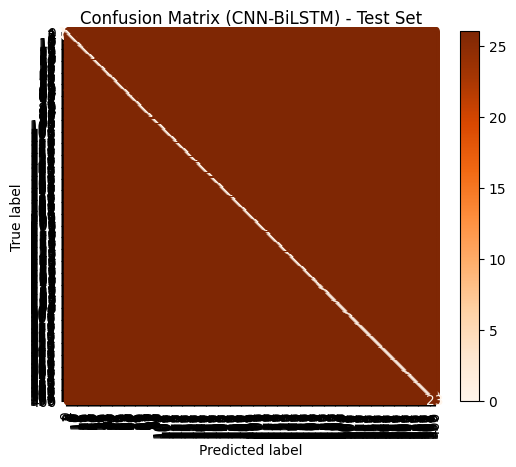

In [25]:
# Load best CNN-BiLSTM model weights
cnn_model.load_state_dict(torch.load(cnn_early_stopping.path))
cnn_model.eval()

cnn_all_preds, cnn_all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        preds = cnn_model(X)
        cnn_all_preds.extend(preds.argmax(1).cpu().numpy())
        cnn_all_labels.extend(y.cpu().numpy())

# Print classification report
print("\nCNN-BiLSTM Classification Report:")
print(classification_report(cnn_all_labels, cnn_all_preds))

# Calculate and print accuracy & WER
cnn_incorrect = sum(1 for r, p in zip(cnn_all_labels, cnn_all_preds) if r != p)
cnn_wer = cnn_incorrect / len(cnn_all_labels)
cnn_accuracy = 1.0 - cnn_wer

print(f"\nTotal Test Samples: {len(cnn_all_labels)}")
print(f"Correct Words: {len(cnn_all_labels) - cnn_incorrect}")
print(f"Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy * 100:.2f}%)")
print(f"Word Error Rate (WER): {cnn_wer:.4f} ({cnn_wer * 100:.2f}%)")

# Plot confusion matrix
cnn_cm = confusion_matrix(cnn_all_labels, cnn_all_preds)
plt.figure(figsize=(42,36))
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm)
disp.plot(cmap="Oranges", xticks_rotation='vertical')
plt.title("Confusion Matrix (CNN-BiLSTM) - Test Set")
plt.show()